In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
da = pd.read_csv("../consensus_wmb/DE_results.csv")
da.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,celltype
0,116.087282,-0.022550,0.234061,-0.096343,0.923248,0.993669,Xkr4,Astro
1,251.071831,0.095420,0.109949,0.867850,0.385476,0.973135,Mrpl15,Astro
2,393.265845,-0.029703,0.073629,-0.403417,0.686641,0.991714,Lypla1,Astro
3,663.450072,0.101254,0.046651,2.170484,0.029970,0.635272,Tcea1,Astro
4,3574.916207,-0.021994,0.172384,-0.127590,0.898474,0.992085,Rgs20,Astro


In [12]:
x = da[da['celltype']=="Astro"]


log2FoldChange
False    20
True     15
Name: True, dtype: int64

In [31]:
tab = da.groupby("celltype").apply(lambda x:pd.crosstab(x['padj']<0.1,x['log2FoldChange']>0).iloc[1,:],include_groups=False)
tab.columns = ['Significant_down_in_female','Significant_up_in_female']
tab = tab.reset_index().melt(id_vars = "celltype")
tab.columns = ["Cell type","DEG type","Number of DEG"]
#sns.barplot(

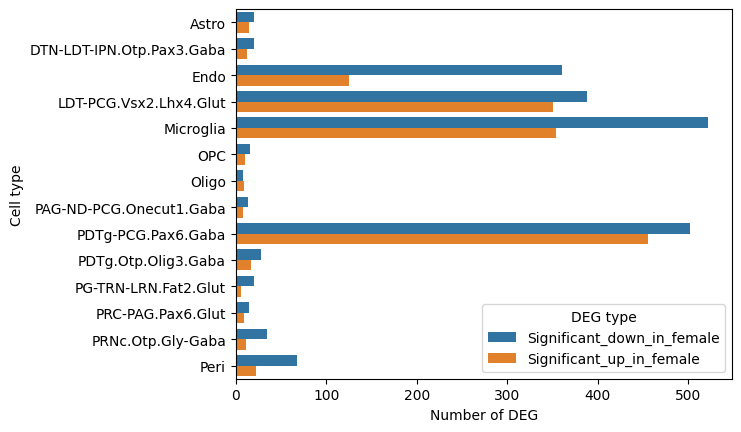

In [36]:
fig,ax = plt.subplots()
ax = sns.barplot(data = tab, y = "Cell type", x = "Number of DEG", hue = "DEG type")
fig.savefig("DEG_barplot.png")

In [28]:
tab

,celltype,variable,value
0,Astro,Significant_down_in_female,20
1,DTN-LDT-IPN.Otp.Pax3.Gaba,Significant_down_in_female,20
2,Endo,Significant_down_in_female,361
3,LDT-PCG.Vsx2.Lhx4.Glut,Significant_down_in_female,388
4,Microglia,Significant_down_in_female,522
5,OPC,Significant_down_in_female,16
6,Oligo,Significant_down_in_female,8
7,PAG-ND-PCG.Onecut1.Gaba,Significant_down_in_female,13
8,PDTg-PCG.Pax6.Gaba,Significant_down_in_female,502
9,PDTg.Otp.Olig3.Gaba,Significant_down_in_female,28
